In [248]:
import pandas as pd

In [247]:
# When I do time trends, I don't include 2025. But when I present aggregates (total complaints, share of other complaints), I do.

# Contextual

In [249]:
# importing dataset of all animals: AWBI scraped dataset
df_all_animal = pd.read_csv("national_with_ai_labels.csv")

#### some quick housekeeping

In [250]:
# importing dataset of state_ids
df_state_id = pd.read_csv("state_ids.csv")

In [251]:
# merging datasets by state_id

df_all_animal =  df_all_animal.merge(
    df_state_id[["state_id", "state_name"]],
    on="state_id", # matches rows using the state_id column
    how="left" # keeps all rows in df_stray, even if a state ID doesn't have a match.
)

# checking if anything didn't match 
df_all_animal[df_all_animal["state_name"].isna()]
#None!

,sr_no,date_of_complaint,complaint_number,complainant_name_org,category_of_complaint,complaint,place_of_incident,violation_of_law,action_initiated,status,date_of_action_taken,state_id,page,ai_animal_type,ai_dog_type,ai_complaint_type,state_name


In [252]:
# cleaning dates (earlier I cleaned but didn't save)
# converting to date-time to YYYY-MM-DD
df_all_animal["date_of_complaint_clean"] = pd.to_datetime( #creating new column
  df_all_animal["date_of_complaint"],
    dayfirst=True, #day comes before month. last = year pandas understands automatically
    errors="coerce" #If pandas finds a value it cannot convert into a date, do not crash. Turn it into NaT.
)

# checking if conversion worked: comparing old and new dates 
df_all_animal[["date_of_complaint", "date_of_complaint_clean"]].head(20)

,date_of_complaint,date_of_complaint_clean
0,12/04/2026,2026-04-12
1,17/03/2026,2026-03-17
2,12/03/2026,2026-03-12
3,04/02/2026,2026-02-04
4,11/01/2026,2026-01-11
5,02/01/2026,2026-01-02
6,30/12/2025,2025-12-30
7,07/12/2025,2025-12-07
8,04/12/2025,2025-12-04
9,24/11/2025,2025-11-24


In [253]:
# confirming data type is correct
df_all_animal["date_of_complaint_clean"].dtype

dtype('<M8[us]')

In [329]:
# checking failed dates
df_all_animal["date_of_complaint_clean"].isna().sum()

np.int64(0)

In [256]:
# creating year column and calling it "complaint_year"
df_all_animal["complaint_year"] = df_all_animal["date_of_complaint_clean"].dt.year

In [257]:
# check whether entire rows are duplicated:
df_all_animal.duplicated().sum()
# no entire rows are duplicated

np.int64(0)

In [258]:
#cleaning complaint text to check duplicates again
df_all_animal["complaint_clean"] = (
    df_all_animal["complaint"]
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df_all_animal["complaint_clean"].duplicated(keep=False).sum()

#37 duplicated complaints

np.int64(37)

In [259]:
#removing exact duplicates 
df_all_animal = df_all_animal.drop_duplicates(subset="complaint_clean", keep="first")
len(df_all_animal)

1101

#### housekeeping done

In [260]:
len(df_all_animal)

1101

In [261]:
# checking date range 
df_all_animal["date_of_complaint_clean"].min(), df_all_animal["date_of_complaint_clean"].max()

(Timestamp('2023-03-27 00:00:00'), Timestamp('2026-05-17 00:00:00'))

In [262]:
df_all_animal["state_name"].value_counts(normalize = True, ascending=False)*100

state_name
Maharashtra                                 15.712988
Uttar Pradesh                               12.806540
Tamil Nadu                                  12.261580
Karnataka                                    6.630336
West Bengal                                  6.357856
Delhi                                        5.903724
Haryana                                      5.722071
Andhra Pradesh                               4.359673
Telangana                                    4.087193
Rajasthan                                    3.814714
Gujarat                                      3.723887
Punjab                                       3.633061
Madhya Pradesh                               2.543143
Kerala                                       2.452316
Uttarakhand                                  1.907357
Bihar                                        1.725704
Odisha                                       1.544051
Assam                                        1.089918
Jharkhand        

* We scraped a table exhibiting 1156 records by running a loop over state IDs. We got 1122 records. The discrepancy of 34 records is likely due to missing state values in those 34 records.
* Within this, we removed exact duplicates of complaints. Thirty-seven records belonged to groups containing identical complaint text. After retaining the first instance of each complaint, 21 repeated records were removed.
* **After all this, we have total complaints = 1101 records between 27th March 2023 and 17th May 2026**

* **State Coverage**
* The dataset covers most of India geographically—31 of 36 states and Union Territories—but it is not evenly nationally representative. No complaints were recorded from Andaman and Nicobar Islands, Goa, Ladakh, Manipur, or Mizoram.
*  Complaints are heavily concentrated in a handful of large states.
*  Maharashtra, Uttar Pradesh and Tamil Nadu alone account for about 41% of complaints.
*  The top five account for about 54%.
*  The top ten account for about 78%.
*  Several northeastern states and smaller Union Territories have only one or two complaints, while five regions have none.

In [263]:
# checking columns
df_all_animal.columns
# key columns are state_name, ai_animal_type, ai_dog_type, ai_complaint_type, date_of_complaint_clean, complaint_year

Index(['sr_no', 'date_of_complaint', 'complaint_number',
       'complainant_name_org', 'category_of_complaint', 'complaint',
       'place_of_incident', 'violation_of_law', 'action_initiated', 'status',
       'date_of_action_taken', 'state_id', 'page', 'ai_animal_type',
       'ai_dog_type', 'ai_complaint_type', 'state_name',
       'date_of_complaint_clean', 'complaint_year', 'complaint_clean'],
      dtype='str')

In [264]:
df_all_animal.head()

,sr_no,date_of_complaint,complaint_number,complainant_name_org,category_of_complaint,complaint,place_of_incident,violation_of_law,action_initiated,status,date_of_action_taken,state_id,page,ai_animal_type,ai_dog_type,ai_complaint_type,state_name,date_of_complaint_clean,complaint_year,complaint_clean
0,1,12/04/2026,9-4/2026-27/3027/PCA,Unknown,-,"On 28.03.2026, a community puppy has been beaten to death by a person because it damaged his footwear. The locals rescued the pup and it was being treated at Humane Animal Society, Coimbatore but in vain. The pup had been suffering despite treatment and succumbed to its injuries on 10.04.2026.\r\n\r\nInjuring and causing death of an animal is a cognizable offense according to law but Tamilnadu Police Department repeatedly refuse to file FIR against the culprits in cases of Animal Cruelty. Hence it is requested that the necessary authorities may kindly be directed to officially register a case against the perpetrator and FIR be registered against the perpetrator.","Kakkan St, Rathinapuri, Tatabad, Coimbatore - 641 027.",-,-,-,21/04/2026,30,1,dog,stray,harm_or_threat_to_dogs,Tamil Nadu,2026-04-12,2026,"on 28.03.2026, a community puppy has been beaten to death by a person because it damaged his footwear. the locals rescued the pup and it was being treated at humane animal society, coimbatore but in vain. the pup had been suffering despite treatment and succumbed to its injuries on 10.04.2026. injuring and causing death of an animal is a cognizable offense according to law but tamilnadu police department repeatedly refuse to file fir against the culprits in cases of animal cruelty. hence it is requested that the necessary authorities may kindly be directed to officially register a case against the perpetrator and fir be registered against the perpetrator."
1,2,17/03/2026,9-4/2025-26/2917/PCA,Doctor Venkatesh,-,"Dr. Venkatesh of Lyka Pet Clinic, Dindigul, had performed ear cropping and tail bobbing aesthetic surgery on a doberman puppy belonging to Mr.Anand, appanaickenpalayam. phone 94430 15017. email : rakkianand22@gmail.com. The surgery was arranged by the breeder Anish of pannimadai, coimbatore, phone 99942 44737. The surgery was done not in a clinic but in the breeders breeding facility under unsanitary , non sterile conditions.",Appanaickenpalayam\r\nCoimbatore,-,-,-,21/04/2026,30,1,dog,pet,harm_or_threat_to_dogs,Tamil Nadu,2026-03-17,2026,"dr. venkatesh of lyka pet clinic, dindigul, had performed ear cropping and tail bobbing aesthetic surgery on a doberman puppy belonging to mr.anand, appanaickenpalayam. phone 94430 15017. email : rakkianand22@gmail.com. the surgery was arranged by the breeder anish of pannimadai, coimbatore, phone 99942 44737. the surgery was done not in a clinic but in the breeders breeding facility under unsanitary , non sterile conditions."
2,3,12/03/2026,9-4/2025-26/2900/PCA,security guards,-,"I am writing to formally bring to your attention a disturbing incident of animal cruelty that occurred inside the campus of Saveetha University, Chennai, Tamil Nadu.\r\n\r\nOn the university premises, specifically in the canteen area, a group of security guards reportedly captured and brutally killed a stray puppy. The act was carried out in a violent and inhumane manner within the campus grounds. This incident has caused significant distress among students and individuals who witnessed or later came to know about the event.\r\n\r\nThe puppy was a harmless stray animal that had been living around the campus. Instead of seeking assistance from authorized animal welfare organizations or following humane methods for handling stray animals, the individuals involved resorted to extreme cruelty, resulting in the death of the puppy. Such actions are deeply concerning and constitute a serious violation of animal protection laws in India.\r\n\r\nThis act appears to be a clear violation of the Prevention of Cruelty to Animals Act, 1960, which prohibits causing unnecessary pain or su

## What % of the AWBI scraped dataset is for dogs v/s other animals?

In [265]:
df_all_animal['ai_animal_type'].value_counts(normalize=True)*100

ai_animal_type
dog        70.481381
unclear     9.445958
cat         8.356040
cow         7.447775
bird        2.724796
horse       1.089918
sheep       0.454133
Name: proportion, dtype: float64

In [266]:
df_all_animal['ai_animal_type'].value_counts()

ai_animal_type
dog        776
unclear    104
cat         92
cow         82
bird        30
horse       12
sheep        5
Name: count, dtype: int64

* Out of the entire complaint dataset, 71% of the complaints (776) were classified as dog-related.
* 8% of the complaints (92) were classified as cat-related.
* 7% of the complaints (82) were classified as cow-related
* 3% of the complaints (30) were classified as bird-related
* 1% of the complaints (12) were classified as horse-related
* 0.4% of the complaints (5) were classified as sheep-related
* 9% of the complaints (104) could not be classified/belonged to other animal types.

## What % of the AWBI scraped dataset for dogs is for pet dogs v/s stray dogs?

In [268]:
#ignore this(just run) (there was a Not Applicable value, where it should have been pet. AI classification mistake. Fixing it here.
df_all_animal.loc[
    (df_all_animal["ai_animal_type"] == "dog") &
    (df_all_animal["ai_dog_type"] == "Not Applicable"),
    "ai_dog_type"
] = "pet"

In [270]:
#with dogs, how many pet v/s stray 
df_all_animal[df_all_animal["ai_animal_type"] == "dog"]["ai_dog_type"].value_counts()

ai_dog_type
stray      487
pet        233
unclear     56
Name: count, dtype: int64

In [271]:
#with dogs, how many pet v/s stray  
df_all_animal[df_all_animal["ai_animal_type"] == "dog"]["ai_dog_type"].value_counts(normalize=True)*100

ai_dog_type
stray      62.757732
pet        30.025773
unclear     7.216495
Name: proportion, dtype: float64

* Amongst the 776 complaints which are about dogs, 63% (487) are classified as stray-dog related and 30% (233) are classified as pet-dog related.
* 56 complaints, which is 7% of all dog-related complaints, could be be classified as stray or pet dog related.

## Did stray dog complaint proportion of my total AWBI dataset increase over time?

In [277]:
# have complaints been increasing over time?
df_all_animal['complaint_year'].value_counts().sort_index()
# yes, complaints / AWBI usage / reporting has been increasing over time.

complaint_year
2023     76
2024    266
2025    663
2026     96
Name: count, dtype: int64

In [334]:
# How did stray dog complaints change each year in absolute numbers?
graph1_data = df_all_animal[df_all_animal["ai_dog_type"] == "stray"]["complaint_year"].value_counts().sort_index()
# sort_index helps me sort the output by years :)
# 2024 complaints were 4.5x greater than 2023 complaints
# 2025 complaints were 2.5x greater than 2024 complaints.
# 11x increase in absolute number of complaints in 2025 from 2023

In [335]:
graph1_data

complaint_year
2023     27
2024    122
2025    304
2026     35
Name: count, dtype: int64

In [279]:
# it is possible overall AWBI complaints only increased in these years, so important to note proportions to conclude
(
    df_all_animal[df_all_animal["ai_dog_type"] == "stray"]
    .groupby("complaint_year")
    .size()
    /
    df_all_animal.groupby("complaint_year").size()
    * 100
)

# Sharp rise in share of stray dog complaints as a part of total AWBI dataset (10%) from 2023 - 2024.

complaint_year
2023    35.526316
2024    45.864662
2025    45.852187
2026    36.458333
dtype: float64

* Stray dog related complaints increased sharply in absolute numbers, rising from 27 complaints in 2023 to 304 complaints in 2025 (an eleven-fold increase).
* This was not simply driven by an increase in overall AWBI complaints (which also had a big jump in 2024 to 2025). The proportion of AWBI complaints involving stray dogs also increased, rising from 35.5% in 2023 to 45.9% in 2024, and remaining at roughly the same level in 2025.
* DISCLAIMER - 2023 is data from MARCH only.

# Main Analysis

## Human - Animal Conflict: Context and Problem Statement
### It is not just human - animal conflict where humans get bitten. Animals suffer. And conflict within humans also increase.

### Did total numbers of complaints involving conflict/harm/threat increase over time?

In [336]:
df_stray_dog = pd.read_csv("data_stray_dog_complaints_R2.csv")

In [337]:
df_stray_dog.columns

Index(['sr_no', 'date_of_complaint', 'complaint_number',
       'complainant_name_org', 'category_of_complaint', 'complaint',
       'place_of_incident', 'violation_of_law', 'action_initiated', 'status',
       'date_of_action_taken', 'state_id', 'page', 'ai_animal_type',
       'ai_dog_type', 'ai_complaint_type', 'date_of_complaint_clean',
       'complaint_year', 'complaint_clean', 'ai_physical_cruelty',
       'ai_removal_or_relocation', 'ai_inst_neglect_inadq_conditions',
       'ai_vehicle_collision_negli_driving', 'ai_other_harm', 'ai_unclear',
       'ai_primary_actor'],
      dtype='str')

In [338]:
len(df_stray_dog)

487

In [282]:
# ignore this 
df_stray_dog.loc[
    df_stray_dog["ai_complaint_type"] == "Not Applicable",
    "ai_complaint_type"
] = "unclear_or_other"

In [339]:
df_stray_dog[df_stray_dog["complaint_year"] != 2026]["ai_complaint_type"].value_counts()

ai_complaint_type
harm_or_threat_to_dogs                265
harm_or_threat_to_dogs_and_feeders    108
harm_or_threat_to_feeders              41
harm_fear_or_nuisance_by_dogs          30
harm_due_to_fear                        6
Not Applicable                          1
unclear_or_other                        1
Name: count, dtype: int64

In [340]:
df_stray_dog[df_stray_dog["complaint_year"] != 2026]['ai_complaint_type'].value_counts(normalize=True)*100

ai_complaint_type
harm_or_threat_to_dogs                58.628319
harm_or_threat_to_dogs_and_feeders    23.893805
harm_or_threat_to_feeders              9.070796
harm_fear_or_nuisance_by_dogs          6.637168
harm_due_to_fear                       1.327434
Not Applicable                         0.221239
unclear_or_other                       0.221239
Name: proportion, dtype: float64

* Between March 2023 and May 2026:
* * ~60% of the complaints (286) classified as stray-dog related alleged harm or threat of harm to dogs
  * 6% (31) of the complaints classified as stray-dog related alleged harm, fear or nuisance by dogs
    
  * 9% (44) of the complaints classified as stray-dog related alleged harm or threat of harm to feeders
  * 24% (117) of the complaints classified as stray-dog related alleged harm or threat of harm to both feeders and dogs

In [179]:
# checking trend of stray dog complaints over years by complaint type
complaint_type_by_year = (
    df_stray_dog
    .groupby("complaint_year")["ai_complaint_type"]
    .value_counts()
    .unstack(fill_value=0)
)

complaint_type_by_year 

ai_complaint_type,harm_due_to_fear,harm_fear_or_nuisance_by_dogs,harm_or_threat_to_dogs,harm_or_threat_to_dogs_and_feeders,harm_or_threat_to_feeders,unclear_or_other
complaint_year,,,,,,
2023,1,0,16,8,2,0
2024,1,10,69,32,9,1
2025,4,20,180,68,30,1
2026,1,1,21,9,3,0


In [186]:
# checking trend of stray dog complaints over years by complaint type
complaint_type_pct_by_year = (
    df_stray_dog
    .groupby("complaint_year")["ai_complaint_type"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)*100

complaint_type_pct_by_year 

ai_complaint_type,harm_due_to_fear,harm_fear_or_nuisance_by_dogs,harm_or_threat_to_dogs,harm_or_threat_to_dogs_and_feeders,harm_or_threat_to_feeders,unclear_or_other
complaint_year,,,,,,
2023,3.703704,0.000000,59.259259,29.629630,7.407407,0.000000
2024,0.819672,8.196721,56.557377,26.229508,7.377049,0.819672
2025,1.320132,6.600660,59.405941,22.442244,9.900990,0.330033
2026,2.857143,2.857143,60.000000,25.714286,8.571429,0.000000


In [175]:
import matplotlib.pyplot as plt

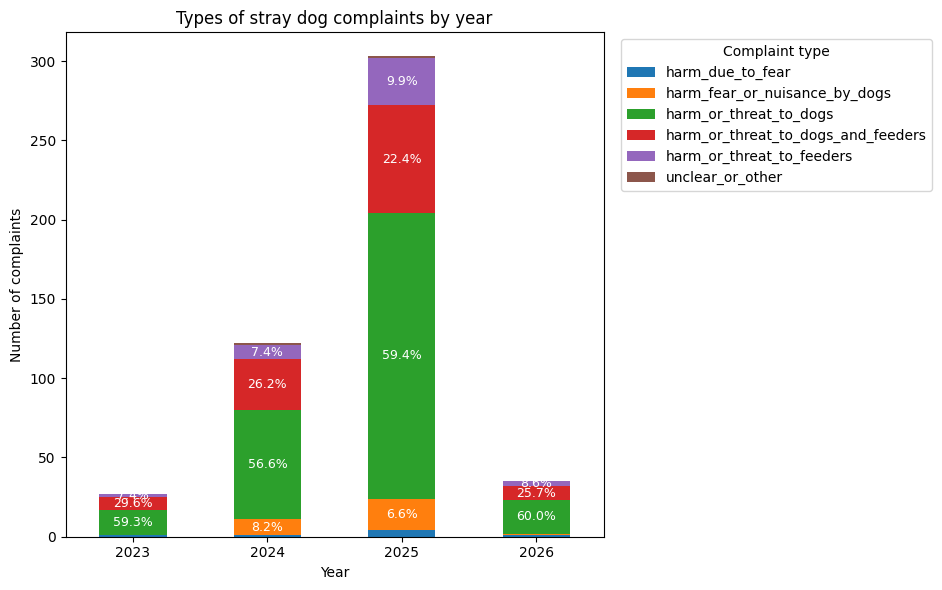

In [184]:
# creating bar chart to understand whats happening
# removing NaN 

# 1. Count complaints by year and complaint type
complaint_type_count_by_year = (
    df_stray_dog
    .groupby("complaint_year")["ai_complaint_type"]
    .value_counts()
    .unstack(fill_value=0)
)

# 2. Calculate percentage share within each year
complaint_type_pct_by_year = (
    complaint_type_count_by_year
    .div(complaint_type_count_by_year.sum(axis=1), axis=0)
    * 100
)

# 3. Plot COUNTS
ax = complaint_type_count_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

# 4. Add percentage labels
for i, container in enumerate(ax.containers):

    # Percentages for the ith complaint type
    pct_values = complaint_type_pct_by_year.iloc[:, i]

    labels = [
        f"{pct:.1f}%" if pct >= 5 else ""
        for pct in pct_values
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="white"
    )

# 5. Formatting
plt.title("Types of stray dog complaints by year")
plt.xlabel("Year")
plt.ylabel("Number of complaints")

plt.legend(
    title="Complaint type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

In [291]:
df_stray_dog['complaint_year'].value_counts().sort_index()

complaint_year
2023     27
2024    122
2025    303
2026     35
Name: count, dtype: int64

* The increase was broad-based across complaint types rather than driven by a shift toward one particular kind of complaint.

**Complaint and Conflict types**

**Time period:** March 2023 – May 2026

### Human–animal conflict: Conflict involving dogs (~66% of stray-dog complaints)

- **60%** of complaints alleged harm or threats directed at stray dogs *(including a small number in which harm to dogs was linked to fear of stray dogs).*
- **6%** of complaints alleged harm, fear, or nuisance caused by stray dogs.

### Human–human conflict: Conflict involving people who care for dogs (~33% of stray-dog complaints)

- **33%** of complaints alleged harm or threats involving dog feeders—either feeders alone or alongside stray dogs.

### Key takeaway

- The complaint records suggest that disputes around stray dogs are **not solely human–animal conflicts**. Around **one in three** complaints also involved alleged conflict between people—particularly between residents, authorities, and those who feed or care for community dogs.
- These proportions remained **broadly stable** even as the total number of stray-dog complaints increased.

## Animal Cruelty: How were dogs allegedly being harmed?

### What was the total number of complaints that alleged harm to dogs? (harm to dogs + harm to dogs and feeders)

In [346]:
df_stray_dog['ai_complaint_type'].value_counts()

ai_complaint_type
harm_or_threat_to_dogs                286
harm_or_threat_to_dogs_and_feeders    117
harm_or_threat_to_feeders              44
harm_fear_or_nuisance_by_dogs          31
harm_due_to_fear                        7
Not Applicable                          1
unclear_or_other                        1
Name: count, dtype: int64

In [293]:
len(df_stray_dog)

487

* Between March 2023 and May 2026, 403 complaints i.e. about 83% of all stray-dog complaints—alleged harm or threats against dogs, either alone or alongside harm to feeders.

### Among complaints alleging harm to dogs, what kinds of harm were reported?

In [311]:
# ignore (fixing AI mistakes)
df_stray_dog.loc[[174, 207, 226, 444], "ai_physical_cruelty"] = "1"
df_stray_dog.loc[[139, 481], "ai_inst_neglect_inadq_conditions"] = "1"

df_stray_dog.loc[316, "ai_complaint_type"] = "harm_fear_or_nuisance_by_dogs"

df_stray_dog.loc[150, "ai_complaint_type"] = "harm_or_threat_to_dogs_and_feeders"

df_stray_dog.loc[
    [49, 150, 192, 231, 458],
    "ai_unclear"
] = "1"

In [312]:
#creating main dataset for harm against dogs
df_harm_type = df_stray_dog[
    df_stray_dog["ai_complaint_type"].isin([
        "harm_or_threat_to_dogs",
        "harm_or_threat_to_dogs_and_feeders"
    ])
]

In [313]:
# checking right conversion 
len(df_harm_type)

402

In [314]:
df_harm_type.columns

Index(['sr_no', 'date_of_complaint', 'complaint_number',
       'complainant_name_org', 'category_of_complaint', 'complaint',
       'place_of_incident', 'violation_of_law', 'action_initiated', 'status',
       'date_of_action_taken', 'state_id', 'page', 'ai_animal_type',
       'ai_dog_type', 'ai_complaint_type', 'date_of_complaint_clean',
       'complaint_year', 'complaint_clean', 'ai_physical_cruelty',
       'ai_removal_or_relocation', 'ai_inst_neglect_inadq_conditions',
       'ai_vehicle_collision_negli_driving', 'ai_other_harm', 'ai_unclear',
       'ai_primary_actor'],
      dtype='str')

In [315]:
df_harm_type[harm_columns].dtypes

ai_physical_cruelty                   str
ai_removal_or_relocation              str
ai_inst_neglect_inadq_conditions      str
ai_vehicle_collision_negli_driving    str
ai_other_harm                         str
dtype: object

In [316]:
#converting all columns to numeric
df_harm_type[harm_columns] = (
    df_harm_type[harm_columns]
    .apply(pd.to_numeric, errors="coerce")
)
df_harm_type[harm_columns].dtypes

ai_physical_cruelty                   int64
ai_removal_or_relocation              int64
ai_inst_neglect_inadq_conditions      int64
ai_vehicle_collision_negli_driving    int64
ai_other_harm                         int64
dtype: object

In [341]:
# shares 
harm_columns = [
    "ai_physical_cruelty",
    "ai_removal_or_relocation",
    "ai_inst_neglect_inadq_conditions",
    "ai_vehicle_collision_negli_driving",
    "ai_other_harm"
]

# Absolute counts
harm_counts = df_harm_type[harm_columns].sum()

# Percentages
harm_percentages = (
    df_harm_type[harm_columns]
    .mean()
    .mul(100)
    .round(1)
)

# Combine into one dataframe
harm_summary = pd.DataFrame({
    "Count": harm_counts,
    "Percent": harm_percentages
})

# Rename rows
harm_summary = harm_summary.rename(index={
    "ai_physical_cruelty": "Physical cruelty",
    "ai_removal_or_relocation": "Removal or relocation",
    "ai_inst_neglect_inadq_conditions": "Institutional neglect / inadequate conditions",
    "ai_vehicle_collision_negli_driving": "Vehicle collision / negligent driving",
    "ai_other_harm": "Other harm"
})

# Sort by count
harm_summary.sort_values("Count", ascending=False)

,Count,Percent
Physical cruelty,296,73.6
Removal or relocation,173,43.0
Vehicle collision / negligent driving,26,6.5
Institutional neglect / inadequate conditions,25,6.2
Other harm,5,1.2


### Key findings

- **Physical cruelty was the most commonly alleged form of harm.** Nearly **three in four (75%, 296)** complaints alleging harm to stray dogs involved allegations of physical cruelty.

- **Illegal removal or relocation was the second most common form of harm.** **43%(173)** of complaints alleged that dogs were illegally removed or relocated, suggesting that relocation is a major source of conflict.

- **Other forms of harm were comparatively uncommon.** Only **6.5%** of complaints (26) alleged vehicle collisions or negligent driving, while **6.2%** (25) alleged institutional neglect or inadequate conditions.

> *These categories are not mutually exclusive. A single complaint may allege multiple forms of harm, so the percentages do not sum to 100%.*

In [ ]:
# CO-OCCURENCE

In [342]:
# how many harm types each complaint contains to fundamentally understand co-occurence
harm_type_summary = (
    df_harm_type[harm_columns]
    .sum(axis=1)
    .value_counts()
    .sort_index()
    .rename_axis("Number of harm types alleged")
    .reset_index(name="Count")
)

# Add percentage column
harm_type_summary["Percent"] = (
    harm_type_summary["Count"] / len(df_harm_type) * 100
).round(1)

harm_type_summary

,Number of harm types alleged,Count,Percent
0,0,6,1.5
1,1,277,68.9
2,2,109,27.1
3,3,10,2.5


* Two-thirds (~70%) of complaints alleged one form of harm only.
* Nearly one-third (~30%) alleged multiple forms of harm (two or three).
* Only 10 complaints (2.5%) alleged three forms of harm simultaneously.
* so we only do pairwise harm categories

In [319]:
#Co-occurence 
from itertools import combinations
import pandas as pd

harm_columns = [
    "ai_physical_cruelty",
    "ai_removal_or_relocation",
    "ai_inst_neglect_inadq_conditions",
    "ai_vehicle_collision_negli_driving",
    "ai_other_harm"
]

# Cleaner names for the output
harm_names = {
    "ai_physical_cruelty": "Physical cruelty",
    "ai_removal_or_relocation": "Removal or relocation",
    "ai_inst_neglect_inadq_conditions": "Institutional neglect",
    "ai_vehicle_collision_negli_driving": "Vehicle collision",
    "ai_other_harm": "Other harm"
}

pair_results = []

# Create every possible pair of harm columns
for harm_1, harm_2 in combinations(harm_columns, 2):

    # True only where BOTH harm types equal 1
    both_harms = (
        (df_harm_type[harm_1] == 1) &
        (df_harm_type[harm_2] == 1)
    )

    # Count how many complaints contain both
    pair_count = both_harms.sum()

    pair_results.append({
        "Harm type 1": harm_names[harm_1],
        "Harm type 2": harm_names[harm_2],
        "Number of complaints with both": pair_count
    })

# Turn the results into a dataframe
harm_pair_summary = pd.DataFrame(pair_results)

# Put the most common overlaps first
harm_pair_summary = harm_pair_summary.sort_values(
    "Number of complaints with both",
    ascending=False
)

harm_pair_summary

,Harm type 1,Harm type 2,Number of complaints with both
0,Physical cruelty,Removal or relocation,99
4,Removal or relocation,Institutional neglect,22
1,Physical cruelty,Institutional neglect,7
2,Physical cruelty,Vehicle collision,4
3,Physical cruelty,Other harm,3
5,Removal or relocation,Vehicle collision,2
6,Removal or relocation,Other harm,2
7,Institutional neglect,Vehicle collision,0
8,Institutional neglect,Other harm,0
9,Vehicle collision,Other harm,0


### Co-occurring forms of harm

**Physical cruelty and removal or relocation frequently appeared together.**
- The most common co-occurring pattern was **physical cruelty alongside removal or relocation**, appearing in **99 complaints** (25% of all complaints related to cruelty against dogs). This suggests that allegations of illegal removal or relocation were often accompanied by allegations of violent capture, handling, or other forms of physical mistreatment. OR
- Among complaints alleging removal or relocation, **57% also alleged physical cruelty**, making this the most common co-occurring pattern.

**Removal or relocation and institutional neglect**
- A second recurring pattern was **removal or relocation alongside institutional neglect**, appearing in **22 complaints**. This may reflect complaints in which dogs were allegedly captured and subsequently kept in inadequate shelter or ABC-centre conditions.

> **Note:** Co-occurrences are reported **pairwise**. A complaint alleging three forms of harm contributes to each relevant pairwise overlap. For example, a complaint alleging physical cruelty, removal or relocation, and institutional neglect is counted in both the *physical cruelty + removal/relocation* and *removal/relocation + institutional neglect* overlaps.

* note - examples to be given from these

In [236]:
# what share of all harm-to-dog complaints alleged both physical cruelty and removal/relocation. 
99 / len(df_harm_type) * 100

25.0

In [237]:
# Among relocation complaints, what percentage also alleged physical cruelty?
99 / harm_summary.loc["Removal or relocation", "Count"] * 100

np.float64(57.22543352601156)

### Alleged Actor

#### In classifiable complaints alleging harm toward dogs, which actors were most frequently accused?

In [238]:
df_harm_type["ai_primary_actor"].value_counts()

ai_primary_actor
individual                         165
resident_group_or_rwa              124
unknown_or_unclear                  40
government_or_public_body           34
private_institution_or_business     19
abc_shelter_or_contractor           14
Name: count, dtype: int64

In [240]:
df_harm_type["ai_primary_actor"].value_counts(normalize=True)*100

ai_primary_actor
individual                         41.666667
resident_group_or_rwa              31.313131
unknown_or_unclear                 10.101010
government_or_public_body           8.585859
private_institution_or_business     4.797980
abc_shelter_or_contractor           3.535354
Name: proportion, dtype: float64

#### Which harm types were most commonly associated with each actor?

In [243]:
harm_columns = [
    "ai_physical_cruelty",
    "ai_removal_or_relocation",
    "ai_inst_neglect_inadq_conditions",
    "ai_vehicle_collision_negli_driving",
    "ai_other_harm"
]

actor_harm = (
    df_harm_type
    .groupby("ai_primary_actor")[harm_columns]
    .mean()
    .mul(100)
    .round(1)
)

actor_harm = actor_harm.rename(columns={
    "ai_physical_cruelty": "Physical cruelty",
    "ai_removal_or_relocation": "Removal or relocation",
    "ai_inst_neglect_inadq_conditions": "Institutional neglect",
    "ai_vehicle_collision_negli_driving": "Vehicle collision",
    "ai_other_harm": "Other harm"
})

actor_harm

,Physical cruelty,Removal or relocation,Institutional neglect,Vehicle collision,Other harm
ai_primary_actor,,,,,
abc_shelter_or_contractor,28.6,92.9,78.6,0.0,0.0
government_or_public_body,52.9,73.5,35.3,2.9,5.9
individual,81.8,22.4,0.0,10.3,1.8
private_institution_or_business,63.2,47.4,5.3,10.5,0.0
resident_group_or_rwa,79.8,59.7,0.0,2.4,0.0
unknown_or_unclear,70.0,37.5,2.5,7.5,0.0


In [321]:
harm_cols = {
    "Physical cruelty": "ai_physical_cruelty",
    "Removal or relocation": "ai_removal_or_relocation",
    "Institutional neglect": "ai_inst_neglect_inadq_conditions",
    "Vehicle collision": "ai_vehicle_collision_negli_driving",
    "Other harm": "ai_other_harm"
}

In [322]:
def get_harm_combination(row):
    selected_harms = [
        label
        for label, col in harm_cols.items()
        if row[col] == 1
    ]

    if not selected_harms:
        return "No coded harm"

    return " + ".join(selected_harms)


df_harm_type["harm_combination"] = df_harm_type.apply(
    get_harm_combination,
    axis=1
)

In [325]:
harm_combination_counts = (
    df_harm_type["harm_combination"]
    .value_counts()
    .rename_axis("harm_combination")
    .reset_index(name="number_of_complaints")
)

harm_combination_counts

,harm_combination,number_of_complaints
0,Physical cruelty,193
1,Physical cruelty + Removal or relocation,89
2,Removal or relocation,58
3,Vehicle collision,22
4,Removal or relocation + Institutional neglect,16
5,Physical cruelty + Removal or relocation + Institutional neglect,6
6,No coded harm,6
7,Institutional neglect,2
8,Physical cruelty + Removal or relocation + Other harm,2
9,Physical cruelty + Vehicle collision,2


In [326]:
rows = []

for harm_label, harm_col in harm_cols.items():

    # Complaints where this harm appears alone
    other_cols = [
        col
        for label, col in harm_cols.items()
        if col != harm_col
    ]

    alone_count = (
        (df_harm_type[harm_col] == 1)
        & (df_harm_type[other_cols].fillna(0).sum(axis=1) == 0)
    ).sum()

    rows.append({
        "harm_type": harm_label,
        "relationship": "Alone",
        "number_of_complaints": int(alone_count)
    })

    # Complaints where this harm co-occurs with each other harm
    for other_label, other_col in harm_cols.items():

        if other_col == harm_col:
            continue

        overlap_count = (
            (df_harm_type[harm_col] == 1)
            & (df_harm_type[other_col] == 1)
        ).sum()

        rows.append({
            "harm_type": harm_label,
            "relationship": f"With {other_label}",
            "number_of_complaints": int(overlap_count)
        })


harm_relationship_counts = pd.DataFrame(rows)
harm_relationship_counts

,harm_type,relationship,number_of_complaints
0,Physical cruelty,Alone,193
1,Physical cruelty,With Removal or relocation,99
2,Physical cruelty,With Institutional neglect,7
3,Physical cruelty,With Vehicle collision,4
4,Physical cruelty,With Other harm,3
5,Removal or relocation,Alone,58
6,Removal or relocation,With Physical cruelty,99
7,Removal or relocation,With Institutional neglect,22
8,Removal or relocation,With Vehicle collision,2
9,Removal or relocation,With Other harm,2


* Among complaints in which an ABC shelter or contractor was the primary alleged actor, 35% alleged physical cruelty, 50% alleged removal or relocation, and 70% alleged institutional neglect.

In [244]:
# biggest actors in physical cruelty
physical_cruelty_by_actor = (
    df_harm_type[df_harm_type["ai_physical_cruelty"] == 1]
    ["ai_primary_actor"]
    .value_counts()
)

physical_cruelty_by_actor

ai_primary_actor
individual                         135
resident_group_or_rwa               99
unknown_or_unclear                  28
government_or_public_body           18
private_institution_or_business     12
abc_shelter_or_contractor            4
Name: count, dtype: int64

In [245]:
# biggest actors in relocation 
relocation_by_actor = (
    df_harm_type[df_harm_type["ai_removal_or_relocation"] == 1]
    ["ai_primary_actor"]
    .value_counts()
)

relocation_by_actor

ai_primary_actor
resident_group_or_rwa              74
individual                         37
government_or_public_body          25
unknown_or_unclear                 15
abc_shelter_or_contractor          13
private_institution_or_business     9
Name: count, dtype: int64

* Resident groups or RWAs were the most frequently named primary alleged actors in complaints involving removal or relocation.
* Individuals are most frequently named primary alleged actors in complaints involving physical cruelty

In [328]:
# biggest actors in inst neglect
instne_by_actor = (
    df_harm_type[df_harm_type["ai_inst_neglect_inadq_conditions"] == 1]
    ["ai_primary_actor"]
    .value_counts()
)

relocation_by_actor

ai_primary_actor
government_or_public_body          12
abc_shelter_or_contractor          11
private_institution_or_business     1
unknown_or_unclear                  1
Name: count, dtype: int64

In [344]:
# co-occurence matrix
label_columns = [
    "ai_physical_cruelty",
    "ai_removal_or_relocation",
    "ai_inst_neglect_inadq_conditions",
    "ai_vehicle_collision_negli_driving",
    "ai_other_harm"
]

labels = (
    df_stray_dog.loc[
        df_stray_dog["complaint_year"] != 2026,
        label_columns
    ]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)

cooccurrence_matrix = labels.T.dot(labels)

clean_names = {
    "ai_physical_cruelty": "Physical cruelty",
    "ai_removal_or_relocation": "Removal or relocation",
    "ai_inst_neglect_inadq_conditions": "Institutional neglect",
    "ai_vehicle_collision_negli_driving": "Vehicle collision",
    "ai_other_harm": "Other harm"
}

cooccurrence_matrix = cooccurrence_matrix.rename(
    index=clean_names,
    columns=clean_names
)

cooccurrence_matrix

,Physical cruelty,Removal or relocation,Institutional neglect,Vehicle collision,Other harm
Physical cruelty,266,92,7,3,3
Removal or relocation,92,164,22,1,2
Institutional neglect,7,22,23,0,0
Vehicle collision,3,1,0,23,0
Other harm,3,2,0,0,5


In [345]:
cooccurrence_matrix.to_csv("cooccurrence_matrix.csv")